In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

In [4]:
data = pd.read_csv("user_artists.dat", sep="\t")
data.columns = ["userId", "songId", "playCount"]

# Limit for speed
data = data.head(5000)

# Normalize to rating (1–5)
data["rating"] = (data["playCount"] - data["playCount"].min()) / (data["playCount"].max() - data["playCount"].min())
data["rating"] = data["rating"] * 4 + 1

print(data.head())

   userId  songId  playCount    rating
0       2      51      13883  1.930211
1       2      52      11690  1.783261
2       2      53      11351  1.760545
3       2      54      10300  1.690120
4       2      55       8983  1.601870


In [5]:
matrix = data.pivot(index='userId', columns='songId', values='rating')

A = matrix.fillna(0).values.astype(np.float32)

print("User-Song Matrix Shape:", A.shape)
print("Sample Matrix:\n", A[:5, :5])

User-Song Matrix Shape: (101, 2612)
Sample Matrix:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [6]:
def rref(matrix):
    A = matrix.astype(float)
    rows, cols = A.shape
    r = 0

    for c in range(cols):
        if r >= rows:
            break

        pivot = np.argmax(abs(A[r:, c])) + r
        if A[pivot, c] == 0:
            continue

        A[[r, pivot]] = A[[pivot, r]]
        A[r] = A[r] / A[r, c]

        for i in range(rows):
            if i != r:
                A[i] = A[i] - A[i, c] * A[r]

        r += 1

    return A

rref_sample = rref(A[:10, :10])
print("RREF (Sample 10x10):\n", rref_sample)

RREF (Sample 10x10):
 [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [7]:
rank = np.linalg.matrix_rank(A[:50, :50])
nullity = A.shape[1] - rank

print("Rank (approx):", rank)
print("Nullity:", nullity)

Rank (approx): 25
Nullity: 2587


In [8]:
basis = rref_sample[np.any(rref_sample != 0, axis=1)]

print("Basis Vectors:\n", basis)

Basis Vectors:
 [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [9]:
def gram_schmidt(X):
    Q = []
    for x in X:
        for q in Q:
            x = x - np.dot(q, x) * q
        if np.linalg.norm(x) > 1e-10:
            x = x / np.linalg.norm(x)
            Q.append(x)
    return np.array(Q)

orthogonal_basis = gram_schmidt(basis)

print("Orthogonal Basis:\n", orthogonal_basis)

Orthogonal Basis:
 [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [10]:
user_vec = A[0][:10]

projection = np.zeros_like(user_vec)

for q in orthogonal_basis:
    projection += np.dot(user_vec, q) * q

print("Projection of User 1 (sample):\n", projection)

Projection of User 1 (sample):
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
# Transpose system for correct dimensions
A_ls = A.T   # (2612 x 101)
b = A[0]     # (2612,)

x_hat = np.linalg.pinv(A_ls) @ b

print("Least Squares Solution Shape:", x_hat.shape)
print("Least Squares Solution (sample):\n", x_hat[:10])

Least Squares Solution Shape: (101,)
Least Squares Solution (sample):
 [ 1.0000000e+00 -1.0040822e-09 -1.6763806e-08  8.8475645e-09
  2.7939677e-09  0.0000000e+00  5.5879354e-09 -2.0954758e-09
  3.7252903e-09  1.1175871e-08]


In [13]:
U, S, Vt = randomized_svd(A, n_components=50)

print("Top Singular Values:", S[:5])

Top Singular Values: [21.935253 15.198991 12.127621 10.96668  10.252912]


In [14]:
k = 50

U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

A_pred = np.dot(np.dot(U_k, S_k), Vt_k)

print("Predicted Matrix Shape:", A_pred.shape)

Predicted Matrix Shape: (101, 2612)


In [15]:
cov_matrix = np.cov(A)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Top Eigenvalues:", eigenvalues[:5].real)

Top Eigenvalues: [0.16864312 0.07741522 0.05627032 0.04566582 0.04025869]


In [16]:
song_ids = matrix.columns.tolist()

def recommend(user_index, n=3):
    print(f"\nUser {user_index + 1} Recommendations:")

    user_ratings = A[user_index]
    predictions = A_pred[user_index]

    unseen = np.where(user_ratings == 0)[0]

    top_items = unseen[np.argsort(predictions[unseen])[::-1][:n]]

    for i in top_items:
        print(f"  → Song ID {song_ids[i]} (Predicted Rating: {round(predictions[i], 2)})")

recommend(0)
recommend(1)
recommend(2)


User 1 Recommendations:
  → Song ID 1009 (Predicted Rating: 0.23000000417232513)
  → Song ID 748 (Predicted Rating: 0.2199999988079071)
  → Song ID 238 (Predicted Rating: 0.2199999988079071)

User 2 Recommendations:
  → Song ID 2044 (Predicted Rating: 0.2199999988079071)
  → Song ID 67 (Predicted Rating: 0.2199999988079071)
  → Song ID 204 (Predicted Rating: 0.1899999976158142)

User 3 Recommendations:
  → Song ID 1384 (Predicted Rating: 0.41999998688697815)
  → Song ID 1375 (Predicted Rating: 0.3799999952316284)
  → Song ID 75 (Predicted Rating: 0.3799999952316284)


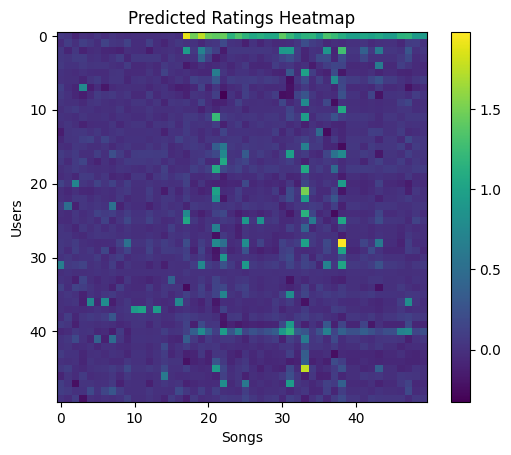

In [17]:
plt.imshow(A_pred[:50, :50])
plt.colorbar()
plt.title("Predicted Ratings Heatmap")
plt.xlabel("Songs")
plt.ylabel("Users")
plt.show()